In [1]:
#Load Libraries
library(Seurat)
library(Signac)
library(GenomeInfoDb)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)
library(AnnotationHub)
library(GenomicRanges)
library(BiocParallel)
library(TFBSTools)
library(SeuratWrappers)
library(data.table)
library(ggplot2)
library(patchwork)
library(reticulate)
library(sceasy)
library(future)
library(Matrix)
library(RColorBrewer)
library(viridis)
library(gplots)
library(circlize)
library(ComplexHeatmap)

#Set Options
options(future.globals.maxSize = 400000 * 1024^2) #for 300GB max size
plan("multicore", workers = 4)

register(SerialParam()) 
set.seed(1234)

#Set working directory
setwd("/storage1/fs1/jmillman/Active/DigitalTwin")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, saveRDS


Loading Seurat v5 beta version 
To maintain compatibility with previous workflows, new Seurat objects will use the previous object structure by default
To use new Seurat v5 assays please run: options(Seurat.object.assay.version = 'v5')

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position,

In [3]:
# Load Data
obj <- readRDS("checkpoints/MultiomeAtlas_integratedFULLpt_annotated.rds")
obj

An object of class Seurat 
1201111 features across 69535 samples within 6 assays 
Active assay: chromvar (720 features, 0 variable features)
 1 layer present: data
 5 other assays present: RNA, ATAC, peaks, integrated.peaks, GeneActivity
 11 dimensional reductions calculated: pca, umap.rna.merged, integrated.cca, umap.integrated.cca, integrated.rpca, umap.integrated.rpca, harmony, umap.harmony, integrated.lsi, lsi, umap.integrated.joint

# Figure 1A - UMAPs

In [3]:
BuYlRd_Ed <- c('#D53E4F','#F46D43','#FDAE61', '#fcd462', '#f0f0a8','#ABD9E9','#74ADD1','#4575B4','#5e4fa2')

obj$dataset <- factor(obj$dataset, 
                            levels=c("s2d1","s3d1","s4d2","s5d1","s5d3","s5d5","s6d1","s6d7","s6d14"))

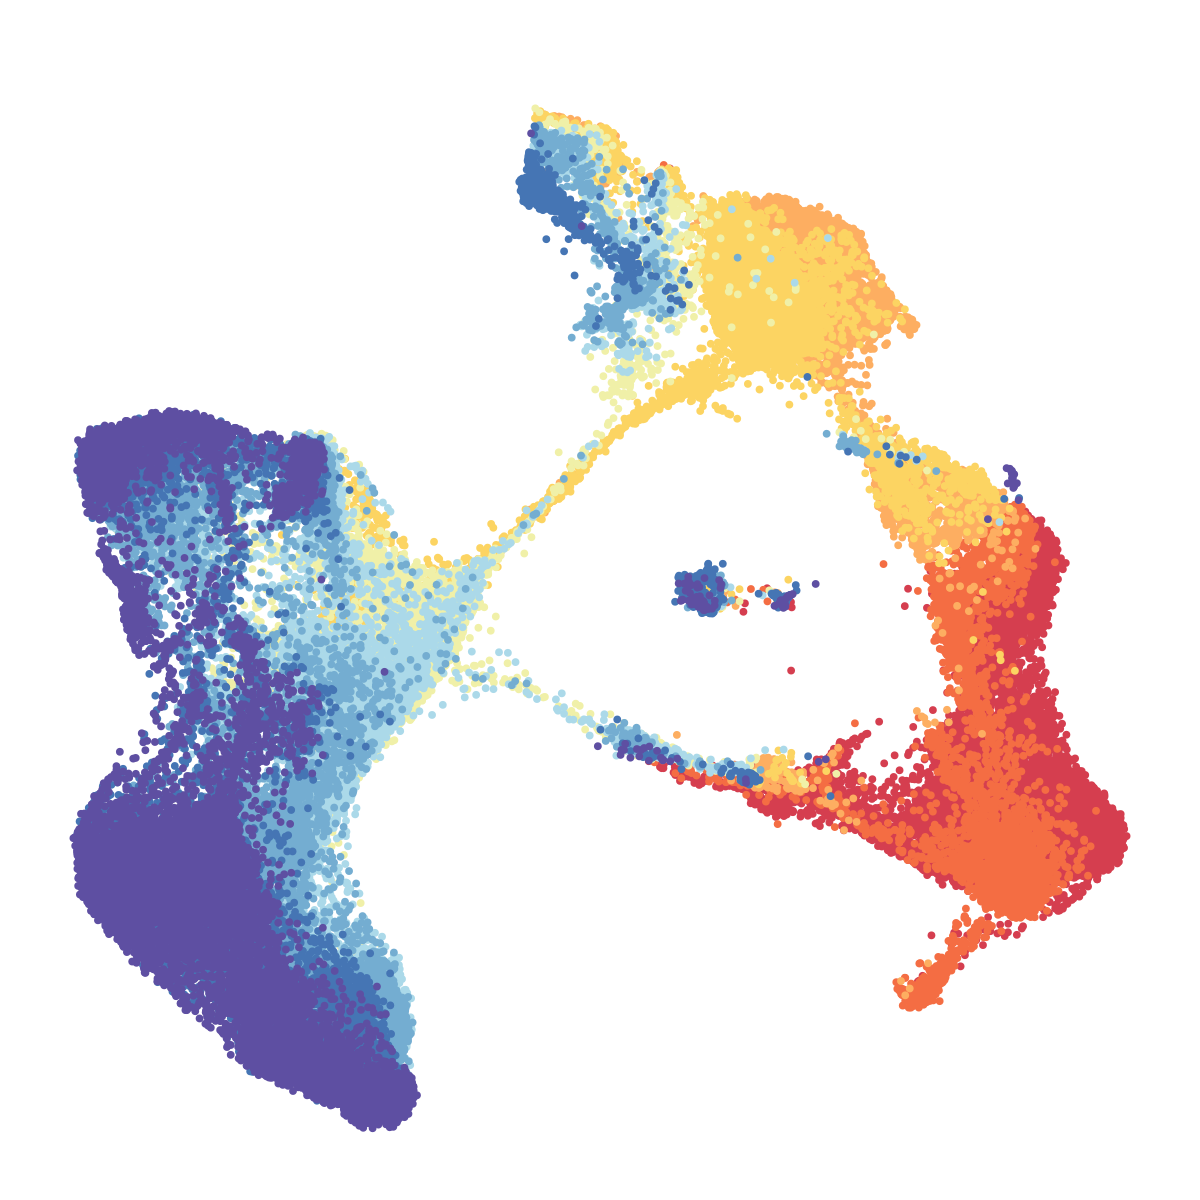

In [4]:
options(repr.plot.width = 10, repr.plot.height = 10) 
DimPlot(obj, reduction = "umap.integrated.joint", group.by = "dataset", label=F, cols=BuYlRd_Ed, pt.size=1) + NoAxes() + ggtitle('') + NoLegend()

# Figure 1B - UMAPs

In [5]:
pal <- c(
  "Mesench." = "#ffbd00",  # yellow
  "Prolif."  = "#CC6677", # dusty rose / muted red
  "DE"       = "#a7defa", # light sky blue
  "GT"       = "#DDCC77", # warm sand / golden khaki
  "PP"       = "#402bad", # deep indigo
  "Exocrine" = "#117733", # forest green
  "UE"       = "#EE3377", # magenta / raspberry
  "eEP"      = "#fcb686", # light orange
  "lEP"      = '#cd853f', #Peru color
  "SIC"       = "#015f94", # royal blue
  #"eSIC"      = "#16baf7", # sky blue
  #"Beta-SIC"     = "#AA4499", # plum / purple-rose
  #"eBeta"       = "#f77785", # light red
  "Beta"        = "#ba0c2f", # WashU red
  "Delta"        = "#7d9e31", # olive
  "Alpha"        = "#f55e07" # vivid orange
)

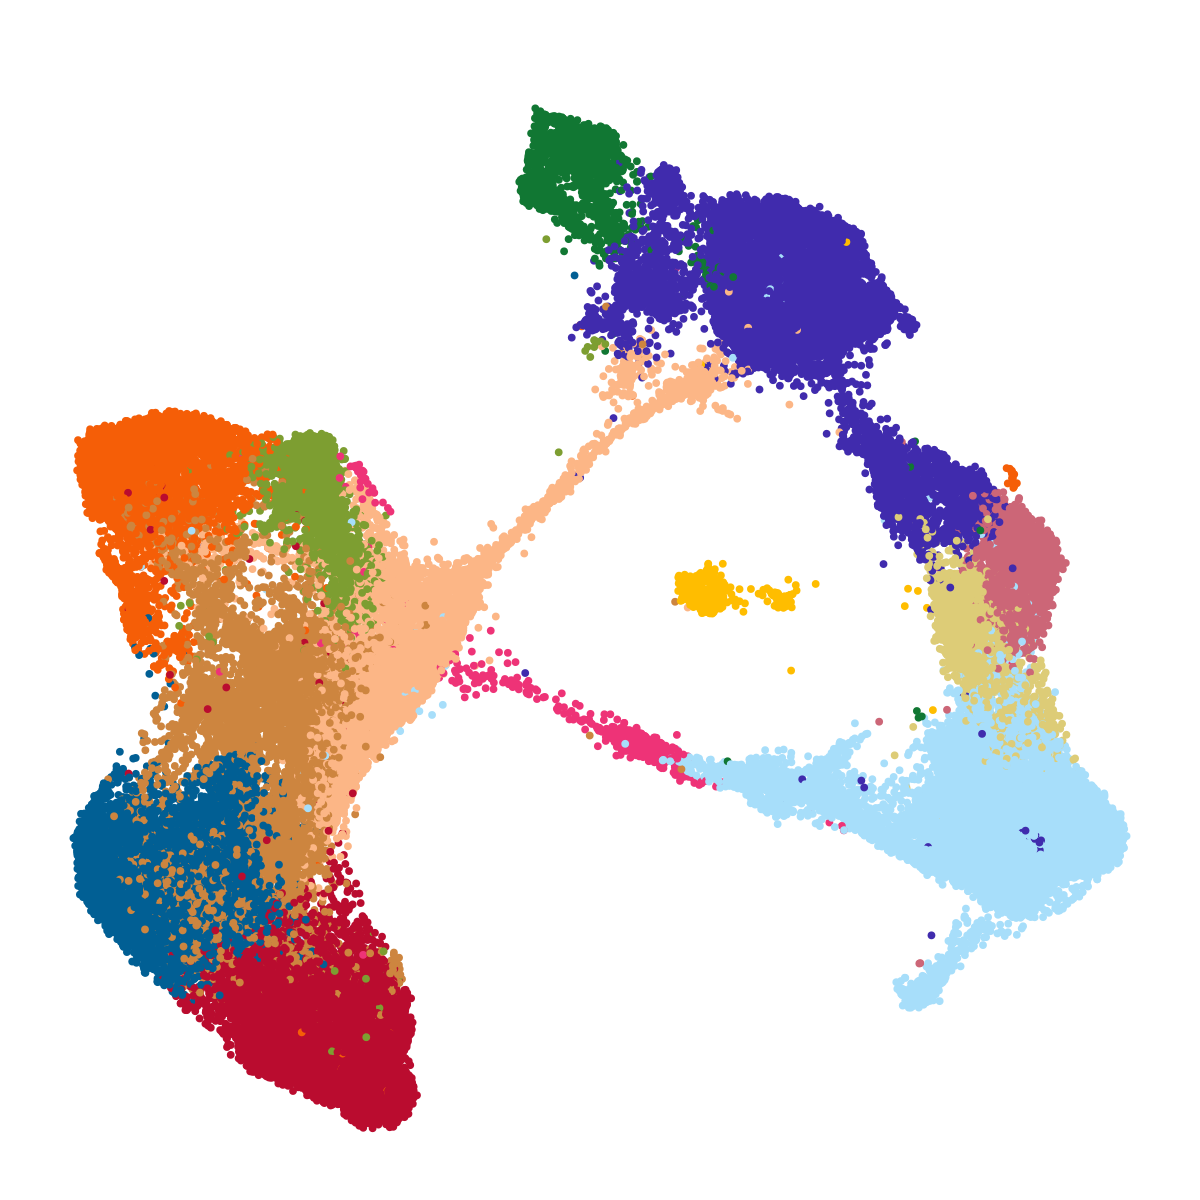

In [6]:
options(repr.plot.width = 10, repr.plot.height = 10) 
DimPlot(obj, reduction='umap.integrated.joint', group.by='celltype', label=F, cols = pal, pt.size=1) + NoAxes() + ggtitle('') +NoLegend()

# Figure 1D - Dot Plots

## Gene Expression

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."


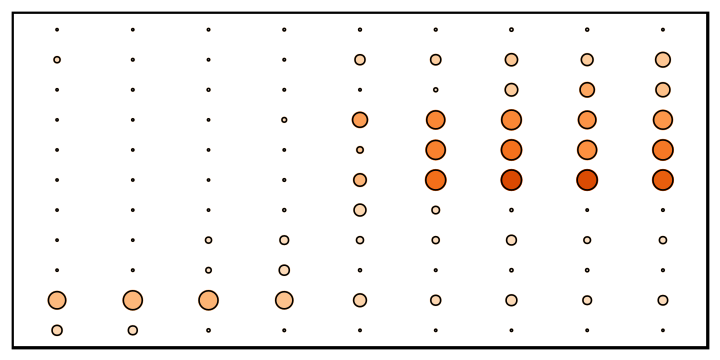

In [10]:
# Palette (same as your FeaturePlots)
oranges_pal <- colorRampPalette(brewer.pal(9, "Oranges")[2:9])

# Gene Expression Dotplot
DefaultAssay(obj) <- "RNA"
Idents(obj) <- "day"

genes <- c("SOX17","GATA4","SOX9","PDX1","NEUROG3","INS","GCG","SST","TPH1","LMX1A","CDX2")

options(repr.plot.width = 6, repr.plot.height = 3)

dp_day <- DotPlot(
  obj,
  features  = genes,
  dot.scale = 5,
  scale     = FALSE    # 🔴 keep raw avg.exp, so 0–8 is meaningful
) +
  NoLegend() +
  geom_point(
    aes(size = pct.exp),
    shape  = 21,
    colour = "black",
    stroke = 0.5
  ) +
  coord_flip() +
  # 🔴 same color scale as FeaturePlot: 0–8, Oranges[2:9]
  scale_colour_gradientn(
    limits  = c(0, 8),
    colours = oranges_pal(100)
  ) +
  NoAxes() +
  guides(
    size = guide_legend(
      override.aes = list(shape = 21, colour = "black", fill = "white")
    )
  ) +
  theme(
    panel.border     = element_rect(colour = "black", fill = NA, size = 1),
    panel.margin     = unit(0, "cm"),
    panel.background = element_rect(fill = "white")
  )

dp_day # Figure 1D

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."


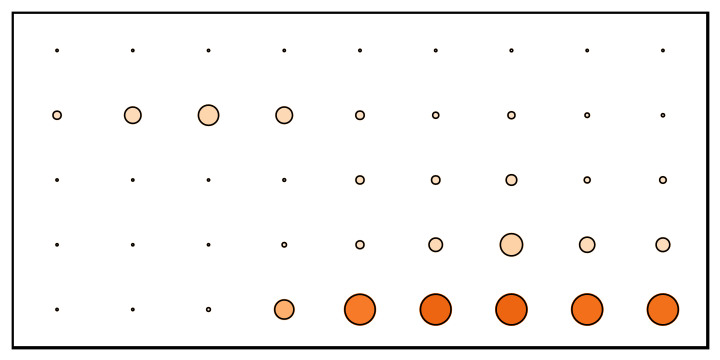

In [22]:
# Palette (same as your FeaturePlots)
oranges_pal <- colorRampPalette(brewer.pal(9, "Oranges")[2:9])

# Gene Expression Dotplot
DefaultAssay(obj) <- "RNA"
Idents(obj) <- "day"

genes <- c("CHGA","NKX6-1","ARX","HHEX","MAFA")

options(repr.plot.width = 6, repr.plot.height = 3)

dp_day <- DotPlot(
  obj,
  features  = genes,
  dot.scale = 8,
  scale     = FALSE    # 🔴 keep raw avg.exp, so 0–8 is meaningful
) +
  NoLegend() +
  geom_point(
    aes(size = pct.exp),
    shape  = 21,
    colour = "black",
    stroke = 0.5
  ) +
  coord_flip() +
  # 🔴 same color scale as FeaturePlot: 0–8, Oranges[2:9]
  scale_colour_gradientn(
    limits  = c(0, 8),
    colours = oranges_pal(100)
  ) +
  NoAxes() +
  guides(
    size = guide_legend(
      override.aes = list(shape = 21, colour = "black", fill = "white")
    )
  ) +
  theme(
    panel.border     = element_rect(colour = "black", fill = NA, size = 1),
    panel.margin     = unit(0, "cm"),
    panel.background = element_rect(fill = "white")
  )

dp_day # Figure S3F

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>."
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
"The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."


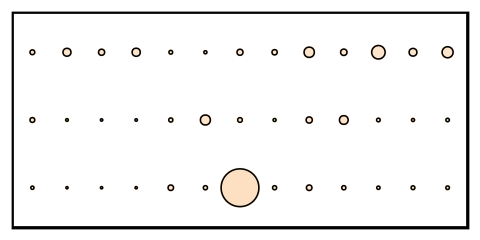

In [4]:
#Ed colors
library(RColorBrewer)

# Palette (same as your FeaturePlots)
purples_pal <- colorRampPalette(brewer.pal(9, "Oranges")[2:9])

# Gene Expression Dotplot
DefaultAssay(obj) <- "RNA"
Idents(obj) <- "celltype"

genes <- c("CDX2", "TAC1", "SCT")

options(repr.plot.width = 4, repr.plot.height = 2)

dp_SIC <- DotPlot(
  obj,
  features  = genes,
  dot.scale = 10,
  scale     = FALSE
) +
  NoLegend() +
  geom_point(
    aes(size = pct.exp),
    shape  = 21,
    colour = "black",
    stroke = 0.5
  ) +
  coord_flip() +
  scale_colour_gradientn(
    limits  = c(0, 8),
    colours = purples_pal(100)
  ) +
  NoAxes() +
  guides(
    size = guide_legend(
      override.aes = list(shape = 21, colour = "black", fill = "white")
    )
  ) +
  theme(
    panel.border     = element_rect(colour = "black", fill = NA, size = 1),
    panel.margin     = unit(0, "cm"),
    panel.background = element_rect(fill = "white")
  )

dp_SIC # Figure S3H

ggsave(
  filename = "outputs/V3_Millman/DotPlot_CDX2_TAC1_SCT.png",
  plot = dp_SIC,
  width = 3.5,
  height = 1.5,
  units = "in",
  dpi = 600
)

## Motif Activity

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message:
"The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead."
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."


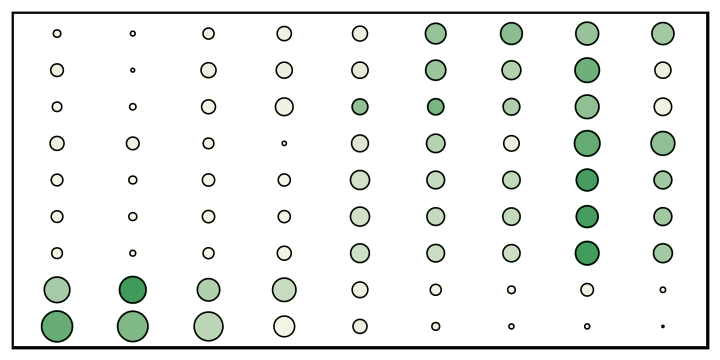

In [16]:
# Motif Activity Dotplot
DefaultAssay(obj) <- 'chromvar'
Idents(obj) <- "day"

#genes <- c("SOX17","GATA4","SOX9","PDX1","NEUROG3","INS","GCG","SST","TPH1","LMX1A","CDX2")
motifs <- c("MA0482.3",#GATA4
            "MA0077.2",#SOX9
            "MA0132.3",#PDX1"
            "MA0674.2",#NKX61"
            "MA0702.3",#LMX1A
            "MA0156.4",#FEV
            "MA0465.3",#CDX2
            "MA0103.4",#ZEB1
            "MA1521.2"#MAFA
)


options(repr.plot.width = 6, repr.plot.height = 3)

dp_motif <- DotPlot(
  obj,
  features  = motifs,
  dot.scale = 8,
  scale     = TRUE    # 🔴 keep raw avg.exp, so 0–8 is meaningful
) +
  NoLegend() +
  geom_point(
    aes(size = pct.exp),
    shape  = 21,
    colour = "black",
    stroke = 0.5
  ) +
  coord_flip() +
  # 🔴 same color scale as FeaturePlot: 0–8, Oranges[2:9]
  scale_colour_gradient2(low = "ivory", mid = "ivory2", high = "springgreen4") +
  NoAxes() +
  guides(
    size = guide_legend(
      override.aes = list(shape = 21, colour = "black", fill = "white")
    )
  ) +
  theme(
    panel.border     = element_rect(colour = "black", fill = NA, size = 1),
    panel.margin     = unit(0, "cm"),
    panel.background = element_rect(fill = "white")
  )

dp_motif # Figure 1D

## Peaks

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Warning message in plot_theme(plot):
"The `panel.margin` theme element is not defined in the element hierarchy."


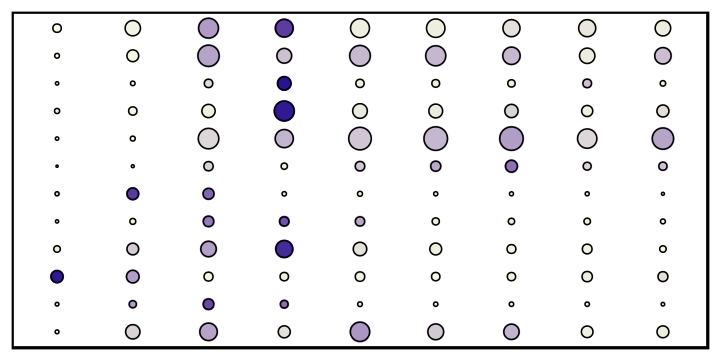

In [26]:
# Peak Accessibility Dotplot
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- "day"

#genes <- c("GATA4","SOX9","PDX1","NEUROG3","CDX2")

peaks = c('chr8-11628441-11629234','chr8-11631310-11631830','chr8-11641495-11643066',#'GATA4
          'chr17-72120833-72122121','chr17-72123220-72124245','chr17-72150973-72152057', #'SOX9',
          'chr13-27911253-27912229','chr13-27917120-27918465','chr13-27919819-27920395','chr13-27927534-27929216', #'PDX1',
          'chr13-27960260-27961306','chr13-27952943-27954813' #CDX2            
)

options(repr.plot.width = 6, repr.plot.height = 3)

dp_peaks <- DotPlot(
  obj,
  features  = peaks,
  dot.scale = 6,
  scale     = TRUE    # 🔴 keep raw avg.exp, so 0–8 is meaningful
) +
  NoLegend() +
  geom_point(
    aes(size = pct.exp),
    shape  = 21,
    colour = "black",
    stroke = 0.5
  ) +
  coord_flip() +
  # 🔴 same color scale as FeaturePlot: 0–8, Oranges[2:9]
  scale_colour_gradient2(low = "ivory", mid = "ivory2", high = "blue4") +
  NoAxes() +
  guides(
    size = guide_legend(
      override.aes = list(shape = 21, colour = "black", fill = "white")
    )
  ) +
  theme(
    panel.border     = element_rect(colour = "black", fill = NA, size = 1),
    panel.margin     = unit(0, "cm"),
    panel.background = element_rect(fill = "white")
  )

dp_peaks # Figure 1D

## Figure S3B-E and S3G and S3I Coverage plots

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


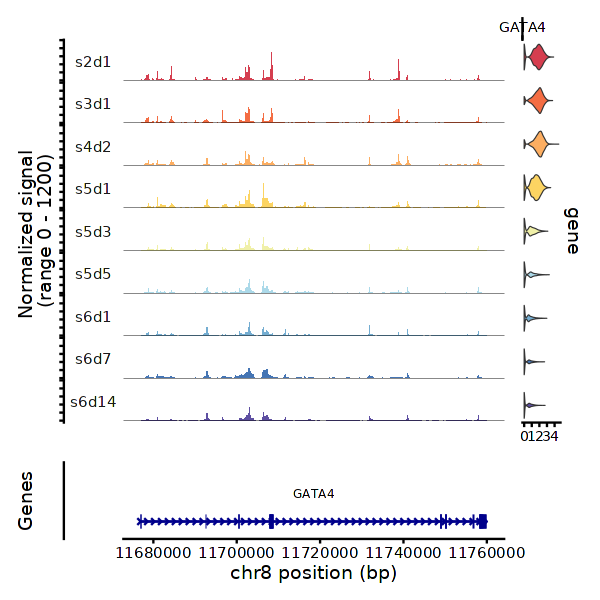

In [32]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'GATA4'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3B

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


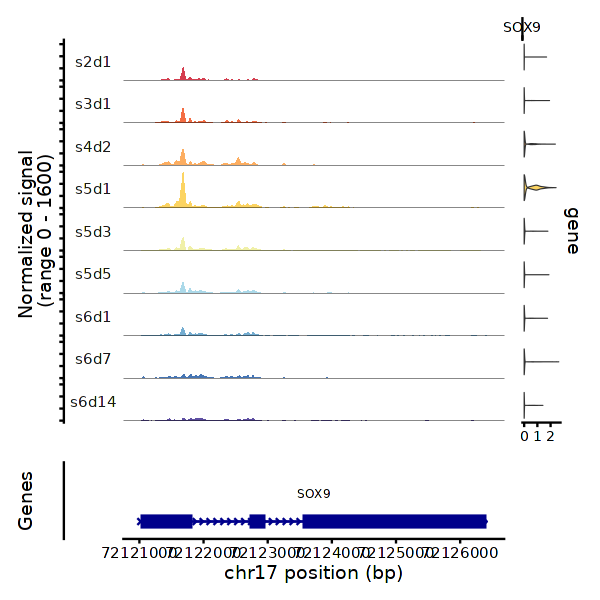

In [33]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'SOX9'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3C

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


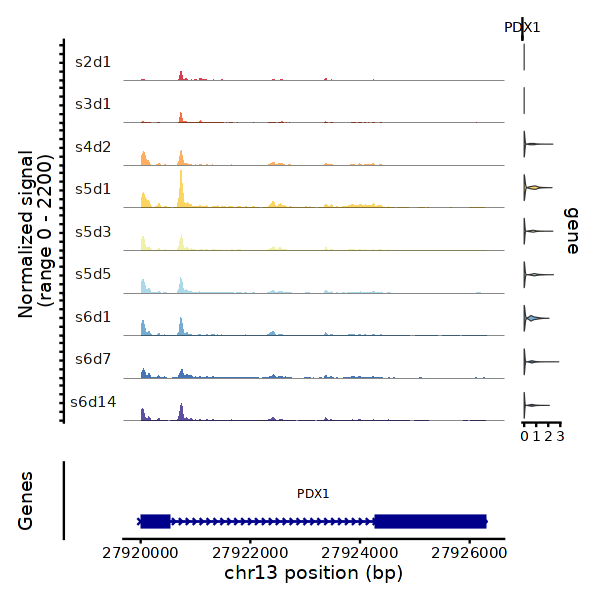

In [34]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'PDX1'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3D

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


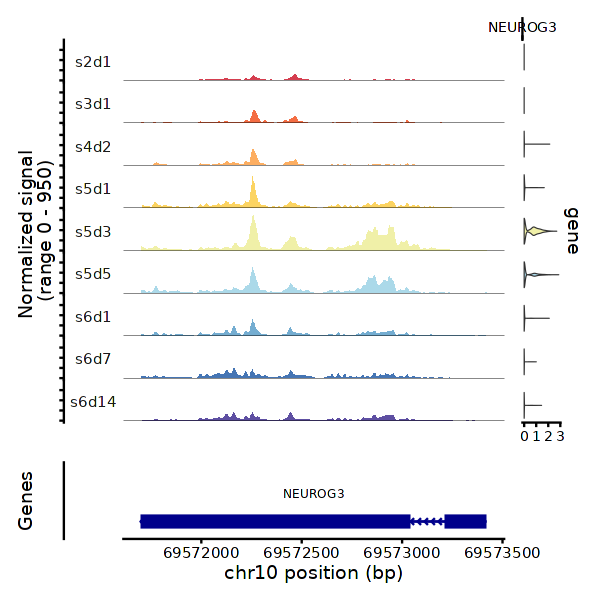

In [35]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'NEUROG3'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
)  # Figure S3E

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 8 rows containing missing values or values outside the scale range
(`geom_segment()`)."
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


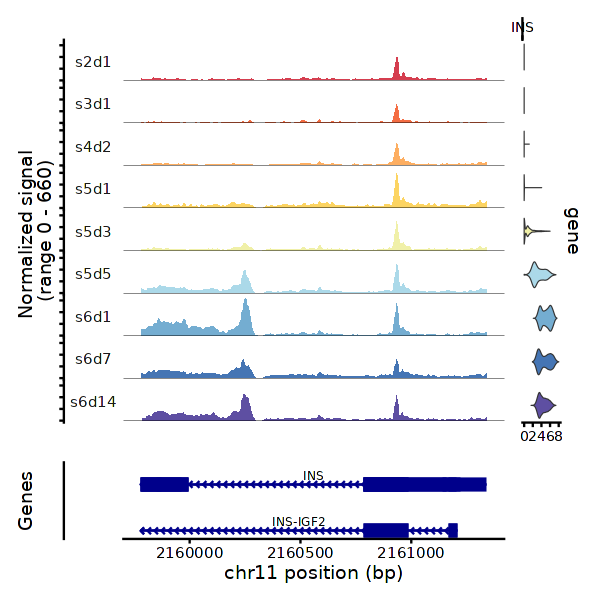

In [10]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'INS'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3G

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


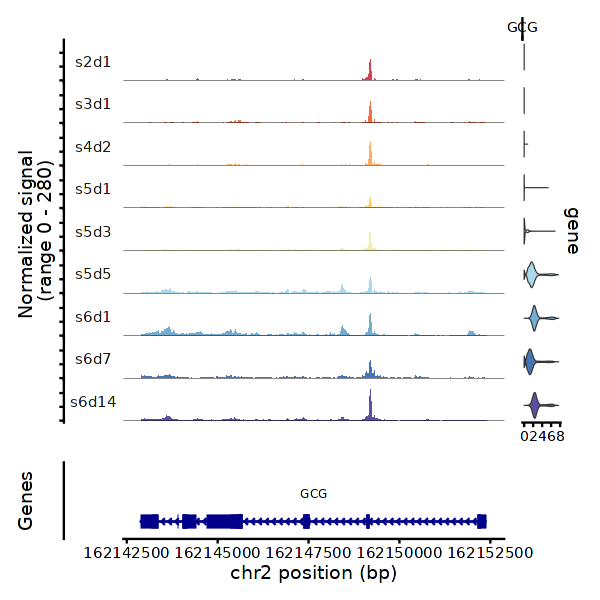

In [11]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'GCG'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3G

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


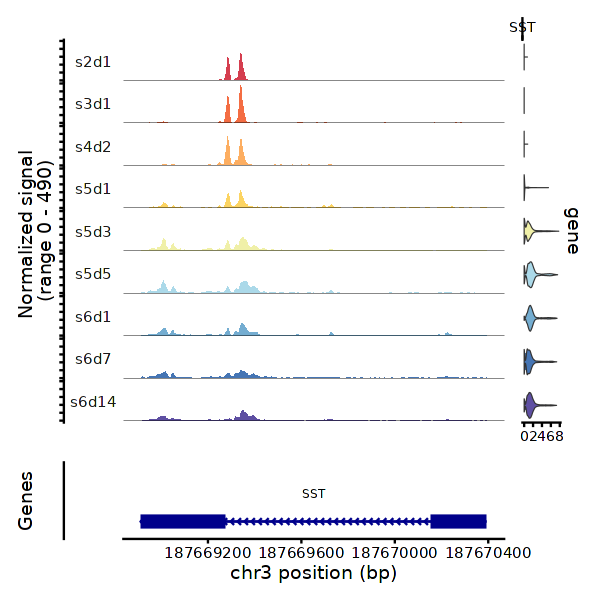

In [12]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'SST'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3G

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


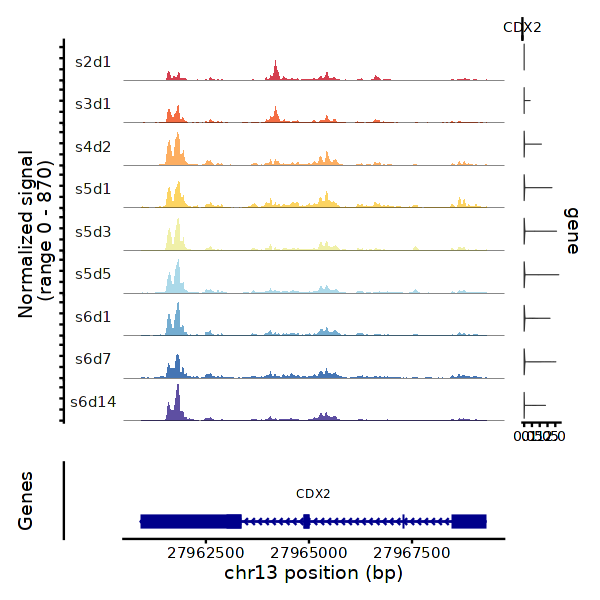

In [13]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'CDX2'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3I

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


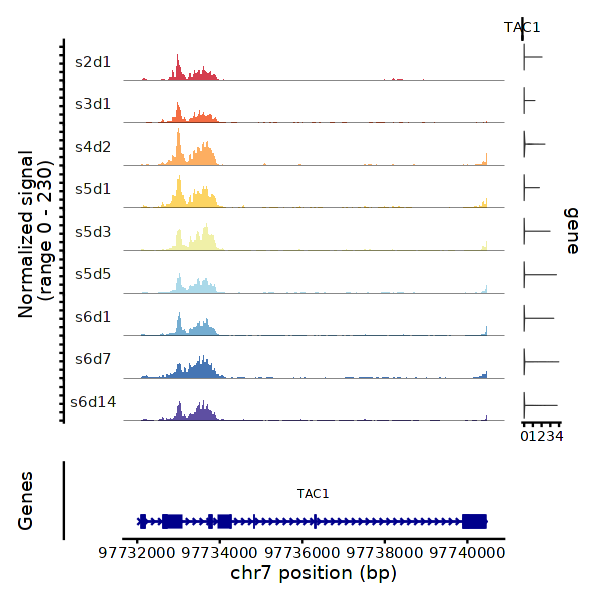

In [14]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'TAC1'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3I

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message:
"Removed 1 row containing missing values or values outside the scale range
(`geom_segment()`)."


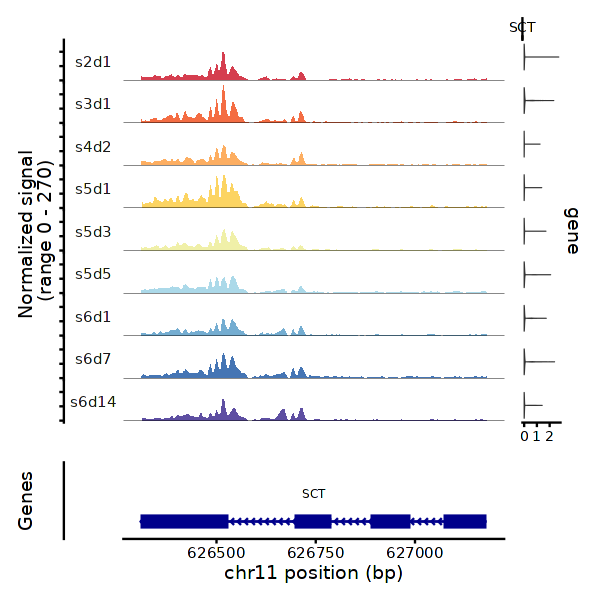

In [15]:
DefaultAssay(obj) <- 'integrated.peaks'
Idents(obj) <- 'dataset'

goi = 'SCT'

options(repr.plot.width = 5, repr.plot.height = 5)

cov_plot <- CoveragePlot(object = obj, region = goi, annotation = FALSE, peaks = FALSE, extend.upstream = 2000, extend.downstream = 8000) + scale_fill_manual(values = BuYlRd_Ed)
gene_plot <- AnnotationPlot(object = obj, region = goi)
expr_plot <- ExpressionPlot(object = obj, features = goi, assay = "RNA") + scale_fill_manual(values = BuYlRd_Ed)

CombineTracks(
  plotlist = list(cov_plot, gene_plot),
  expression.plot = expr_plot,
  heights = c(10, 2),
  widths = c(10, 1)
) # Figure S3I

# Figure 1E

In [ ]:
# Load Data
obj <- readRDS("checkpoints/MultiomeAtlas_integratedFULLpt_annotated.rds")
obj

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


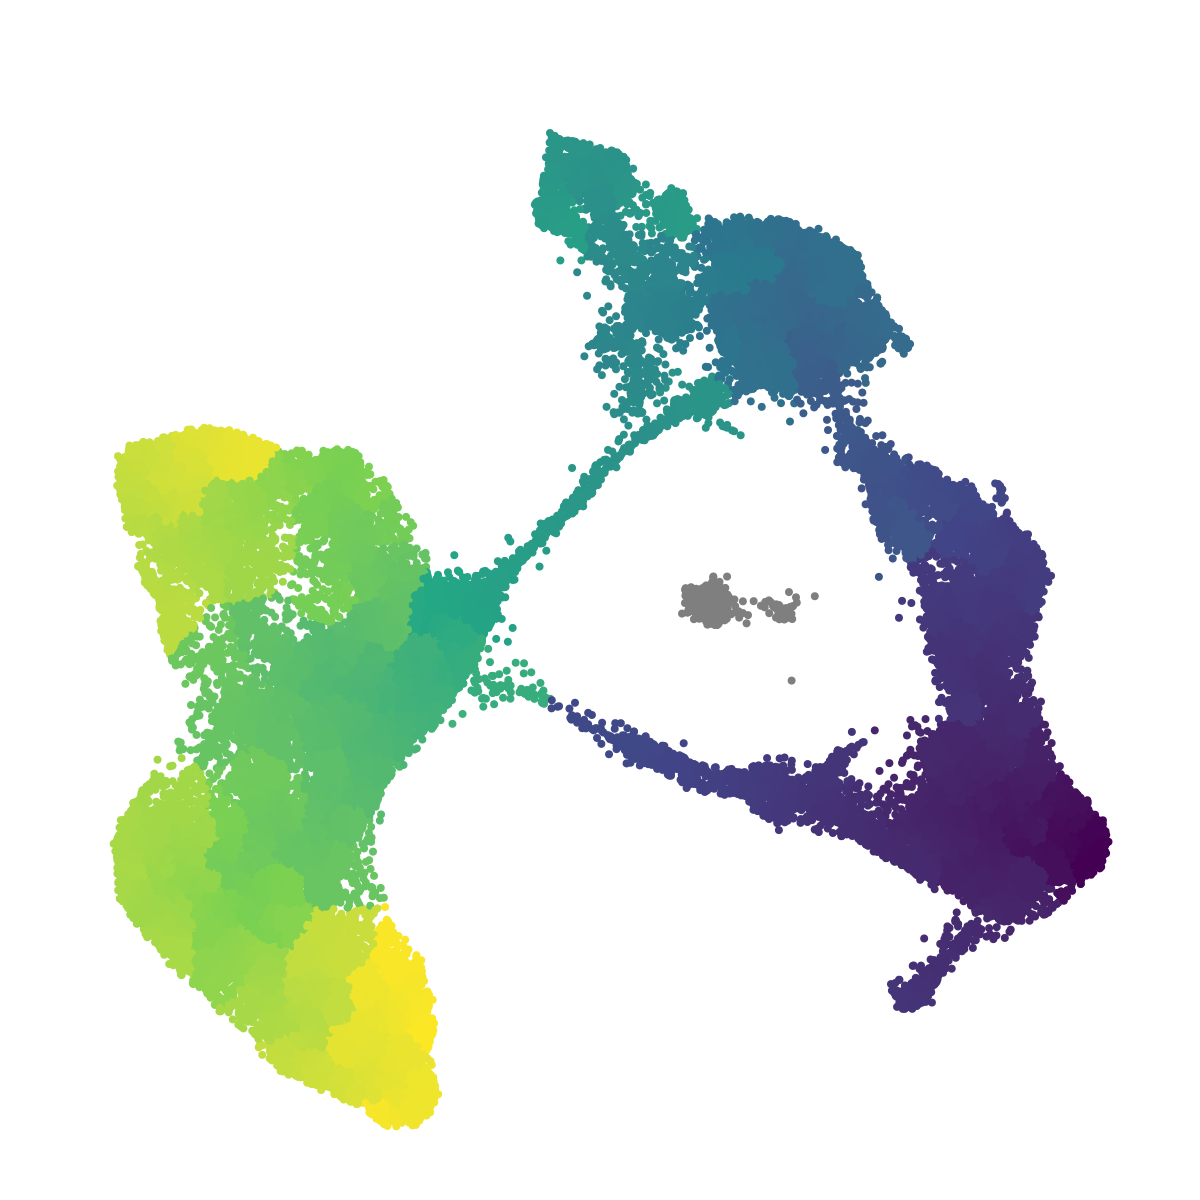

In [5]:
options(repr.plot.width = 10, repr.plot.height = 10)
FeaturePlot(obj, c('pseudotime'), reduction = 'umap.integrated.joint', pt.size=1) + NoAxes() +ggtitle('') +NoLegend() +scale_color_viridis_c()
# Figure 1E

In [ ]:
# The present has no ribbon, Your gift keeps on giving - Get Lucky by Daft Punk